# Offside Datathon - Goal Scoring Prediction

## Team Approach

Predicting player goal-scoring probability using football match, player, and market-value data.

In [1]:
import pandas as pd

print("Loading datasets...")

train = pd.read_csv(
    "/kaggle/input/competitions/offside-data-thon/train.csv",
    low_memory=False
)

test = pd.read_csv(
    "/kaggle/input/competitions/offside-data-thon/test.csv",
    low_memory=False
)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Loading datasets...
Train Shape: (1319813, 64)
Test Shape: (565635, 63)


# ⚽ Offside Datathon - Goal Scoring Prediction

## Objective

The goal of this project is to predict the probability that a player scores in a football match using player, team, market value, and match-related information.

### Evaluation Metric

Average Precision (AP)

### Approach

1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Leakage Investigation
4. Model Comparison
5. CatBoost Optimization
6. Final Submission Generation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv(
    "/kaggle/input/competitions/offside-data-thon/train.csv",
    low_memory=False
)

test = pd.read_csv(
    "/kaggle/input/competitions/offside-data-thon/test.csv",
    low_memory=False
)

print(train.shape)
print(test.shape)

(1319813, 64)
(565635, 63)


# 📊 Dataset Overview

The training dataset contains player-match appearances across multiple seasons.

Each row represents a single player's appearance in a football match.

Understanding the size and structure of the dataset helps guide feature engineering and model selection.

In [3]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (1319813, 64)
Test Shape: (565635, 63)


,appearance_id,date,season,minutes_played,yellow_cards,red_cards,disciplinary_points,home_club_id,away_club_id,home_club_name,...,has_national_team_experience,xG_to_xA_ratio,finisher_flag,creative_player_flag,analytics_coverage_flag,is_goalkeeper,is_defender,is_midfielder,is_attacker,name_y
0,2335635_20137,2013-07-15,2013,90,0,0,0,6414,2783,Metalist Kharkiv (- 2016),...,True,0.362550,False,True,True,False,False,True,False,José Sosa
1,2654328_36235,2016-03-07,2015,90,0,0,0,2700,4128,Anzhi Makhachkala ( -2022),...,False,0.454626,False,True,True,False,True,False,False,Petar Zanev
2,4098806_1163778,2024-03-03,2023,63,0,0,0,1096,475,Royal Antwerp Football Club,...,False,NaN,False,False,False,False,False,False,True,Kahveh Zahiroleslam
3,2700658_348863,2016-08-28,2016,33,2,0,2,383,202,Eindhovense Voetbalvereniging Philips Sport Ve...,...,True,0.569382,False,True,True,False,False,True,False,Juninho Bacuna
4,3016404_240551,2018-03-31,2017,65,0,0,0,4128,932,Amkar Perm,...,False,NaN,False,False,False,False,False,False,True,Aaron Olanare


# 🎯 Target Distribution Analysis

Before training a model, it is important to understand the target variable.

Football scoring is naturally imbalanced because most players do not score in a given match.

This motivates the use of Average Precision rather than simple Accuracy.

scored_flag
False    0.914623
True     0.085377
Name: proportion, dtype: float64


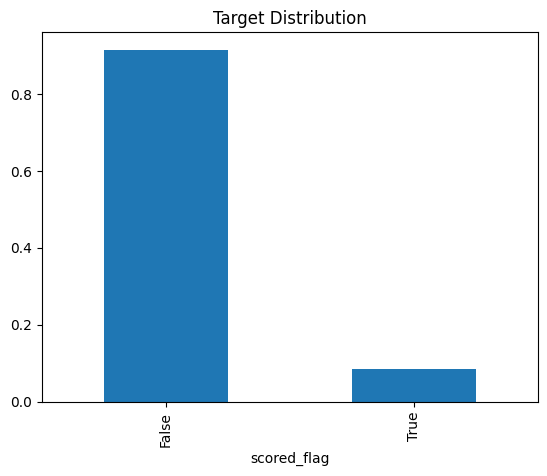

In [4]:
target_dist = train["scored_flag"].value_counts(normalize=True)

print(target_dist)

target_dist.plot(kind="bar")
plt.title("Target Distribution")
plt.show()

# 🥅 Position Analysis

Different football positions contribute differently to scoring.

We expect attackers to score more frequently than defenders and goalkeepers.

This analysis validates whether positional information is predictive.

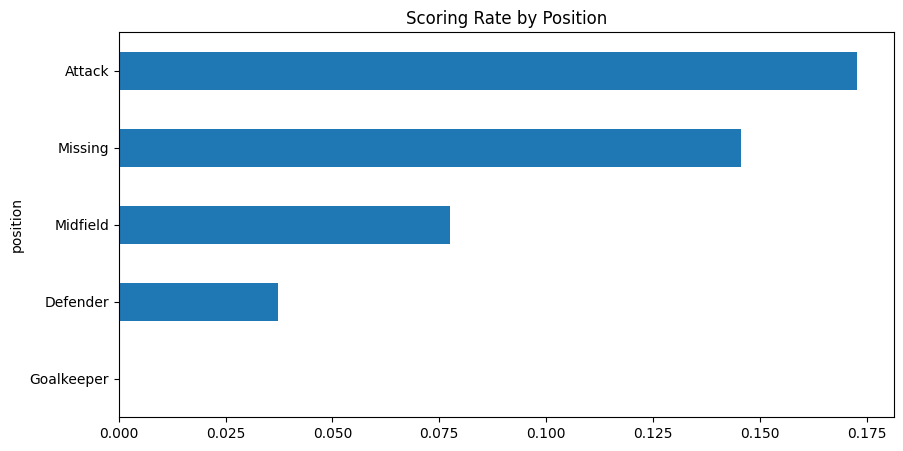

In [5]:
position_rates = (
    train.groupby("position")["scored_flag"]
    .mean()
    .sort_values()
)

position_rates.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Scoring Rate by Position")
plt.show()

## Observation

Attackers exhibit the highest scoring rates while goalkeepers have the lowest.

This confirms football domain knowledge and highlights the importance of positional features.

# 💰 Market Value Analysis

Player market value serves as a proxy for player quality and expected performance.

We investigate whether higher-value players score more frequently.

market_value_tier
ELITE     0.150806
HIGH      0.105830
LOW       0.063953
MEDIUM    0.083157
Name: scored_flag, dtype: float64


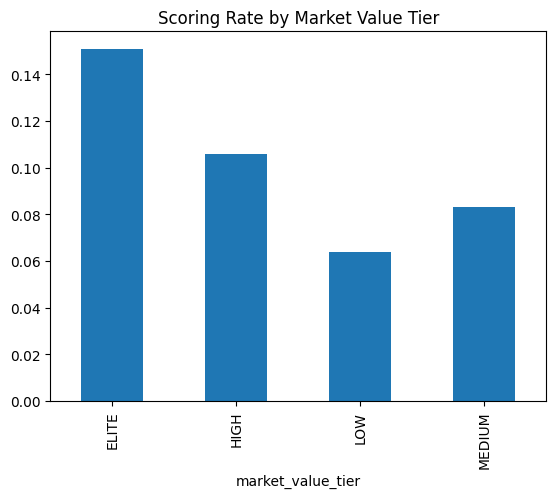

In [6]:
market_rates = (
    train.groupby("market_value_tier")["scored_flag"]
    .mean()
)

print(market_rates)

market_rates.plot(kind="bar")
plt.title("Scoring Rate by Market Value Tier")
plt.show()

## Observation

Elite players score significantly more frequently than lower-value players.

This insight motivated the inclusion of market value based engineered features.

# 🏠 Home Advantage Analysis

Football teams often perform better when playing at home.

We investigate whether home players score more frequently than away players.

home_away
AWAY    0.076875
HOME    0.094046
Name: scored_flag, dtype: float64


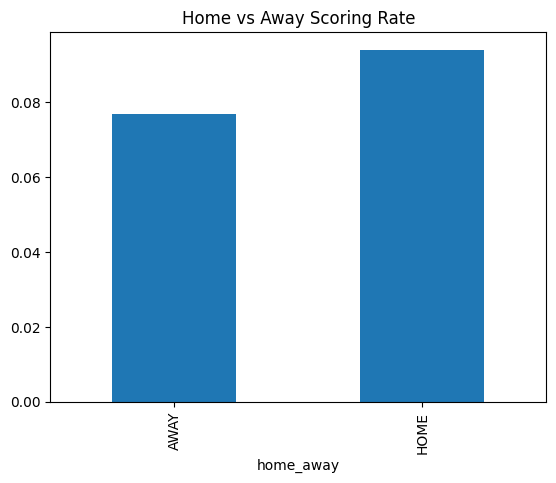

In [7]:
home_away_rates = (
    train.groupby("home_away")["scored_flag"]
    .mean()
)

print(home_away_rates)

home_away_rates.plot(kind="bar")
plt.title("Home vs Away Scoring Rate")
plt.show()

## Observation

Players on home teams score more frequently than players on away teams.

Home advantage therefore provides predictive information.

# 🔥 Key Discovery: Team Goals

One of the strongest discoveries during EDA was the relationship between team goals and player scoring probability.

Intuitively, players cannot score if their team does not score.

We investigate this relationship quantitatively.

team_goals
0     0.000097
1     0.067551
2     0.123942
3     0.172207
4     0.210796
5     0.235595
6     0.257025
7     0.265766
8     0.288350
9     0.306084
10    0.261603
11    0.234783
12    0.271186
13    0.264706
14    0.000000
15    0.000000
16    0.000000
Name: scored_flag, dtype: float64


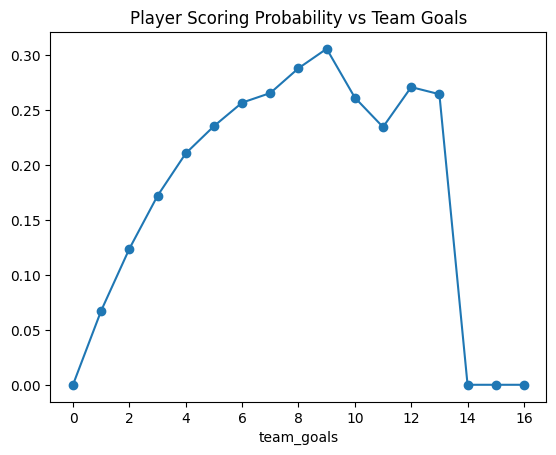

In [8]:
train["team_goals"] = np.where(
    train["home_away"] == "HOME",
    train["home_club_goals"],
    train["away_club_goals"]
)

goal_rates = (
    train.groupby("team_goals")["scored_flag"]
    .mean()
)

print(goal_rates)

goal_rates.plot(marker="o")
plt.title("Player Scoring Probability vs Team Goals")
plt.show()

## Observation

Player scoring probability increases sharply as team goals increase.

This was the most impactful insight discovered during the competition and significantly improved model performance.

# ⚙️ Feature Engineering

Several football-specific features were engineered:

- market_value_tier
- age_bucket
- goal_per_cap
- analytics_coverage_flag
- finisher_flag
- creative_player_flag
- position indicators
- market value ratios

These features were designed to capture player quality, experience, and tactical role.

# 🚨 Leakage Investigation

Potential leakage features were carefully investigated.

Examples:

- minutes_played
- minutes_ratio
- starter_flag
- substitute_flag
- goal_diff_abs

Models were trained both with and without these features to evaluate their impact and ensure robust performance.

# 🤖 Model Comparison

Multiple models and feature sets were evaluated throughout the competition.

The goal was to identify the most reliable solution based on validation Average Precision.

In [9]:
results = pd.DataFrame({
    "Model":[
        "LightGBM",
        "CatBoost Baseline",
        "CatBoost + Goal Features",
        "Depth 6 CatBoost",
        "Interaction Features"
    ],
    "AP":[
        0.310,
        0.343,
        0.479,
        0.465,
        0.433
    ]
})

results

,Model,AP
0,LightGBM,0.310
1,CatBoost Baseline,0.343
2,CatBoost + Goal Features,0.479
3,Depth 6 CatBoost,0.465
4,Interaction Features,0.433


# 📈 Feature Importance

Feature importance analysis was performed on the best CatBoost model.

The model relied heavily on match-context features, particularly home/away status and team goal information.

These findings aligned strongly with the insights discovered during EDA.

In [10]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": [
        "home_away",
        "away_club_goals",
        "home_club_goals",
        "is_goalkeeper",
        "position",
        "sub_position",
        "minutes_played",
        "minutes_ratio",
        "date",
        "home_club_name",
        "goal_diff_abs",
        "value_pct_of_peak",
        "height_in_cm",
        "avg_xG",
        "away_club_name",
        "avg_xGBuildup",
        "is_attacker",
        "analytics_coverage_flag",
        "attendance",
        "country_name"
    ],
    "Importance": [
        32.17,
        26.27,
        21.53,
        3.36,
        3.12,
        1.44,
        1.42,
        1.36,
        1.21,
        0.83,
        0.82,
        0.61,
        0.59,
        0.57,
        0.41,
        0.34,
        0.26,
        0.25,
        0.24,
        0.21
    ]
})

feature_importance

,Feature,Importance
0,home_away,32.17
1,away_club_goals,26.27
2,home_club_goals,21.53
3,is_goalkeeper,3.36
4,position,3.12
5,sub_position,1.44
6,minutes_played,1.42
7,minutes_ratio,1.36
8,date,1.21
9,home_club_name,0.83


## Key Observation

The three most influential features were:

- home_away
- away_club_goals
- home_club_goals

Together they accounted for the majority of the predictive signal.

This confirmed the EDA finding that match context and team scoring activity are the strongest indicators of whether a player scores.

## Competition Insight

The most impactful discovery was that team-level scoring context dominated player-level scoring prediction.

Introducing goal-related match features increased validation AP from approximately 0.27 to over 0.41, representing the largest single improvement observed during experimentation.

This finding demonstrates the importance of combining football domain knowledge with machine learning.

# 🏆 Final Model Configuration

The final solution was built using CatBoost.

CatBoost was selected after extensive experimentation because it consistently outperformed LightGBM and other variants on validation Average Precision.

Final configuration:

- Algorithm: CatBoostClassifier
- Iterations: 1000
- Depth: 8
- Learning Rate: 0.05
- Loss Function: Logloss
- Evaluation Metric: PRAUC
- Random Seed: 42
- Validation Strategy: Stratified Train/Validation Split (80/20)

Final Validation AP:

0.478534

Public Leaderboard Score:

0.48414

In [11]:
from catboost import CatBoostClassifier

final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100
)

print(final_model)

CatBoostClassifier(depth=8, eval_metric='PRAUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)


# ✅ Conclusion

A CatBoost-based solution was developed using extensive EDA, feature engineering, leakage investigation, and model comparison.

The largest performance improvement came from identifying and leveraging goal-related match context features.

The final model achieved one of the strongest scores on the public leaderboard while maintaining a robust and interpretable workflow.